In [112]:
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. 데이터 로딩
data = pd.read_csv("/content/drive/MyDrive/Social_Network_Ads.csv")

# 2. 데이터 전처리, Feature 추출
X = data[['Age', 'EstimatedSalary']].values
y = data['Purchased'].values

# 3. 학습 데이터를 데이터의 80%, 테스트 데이터를 20%로 분할 사용
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 4. 데이터 스케일링 (정규화)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# X에 bias 항 추가 (첫 번째 열에 1을 추가)
X_train = np.c_[np.ones(X_train.shape[0]), X_train]  # (m, n) -> (m, n+1)
X_test = np.c_[np.ones(X_test.shape[0]), X_test]  # (m, n) -> (m, n+1)

# 시그모이드 함수
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 예측 함수 (Hypothesis function)
def h(X, w):
    return sigmoid(np.dot(X, w))

# 비용 함수
def compute_cost(X, y, w):
    m = X.shape[0]
    z = np.dot(X, w)
    h_val = sigmoid(z)
    epsilon = 1e-5  # log(0) 방지용
    cost = -(1/m) * np.sum(y * np.log(h_val + epsilon) + (1 - y) * np.log(1 - h_val + epsilon))
    return cost

# 5. 경사하강법을 이용해서 모델을 학습하고, 파라미터 값 출력
alpha = 0.01  # 학습률
iterations = 10000

# w는 (n+1,) 크기, 즉 bias 항을 포함하여 초기화
w = np.zeros(X_train.shape[1])  # (n+1,)

# 경사하강법
for i in range(iterations):
    gradient = np.dot(X_train.T, (h(X_train, w) - y_train)) / len(y_train)  # 기울기 계산
    w -= alpha * gradient  # 가중치 업데이트

# 파라미터 출력
print(w)


[-0.90072599  2.1329353   1.15122276]


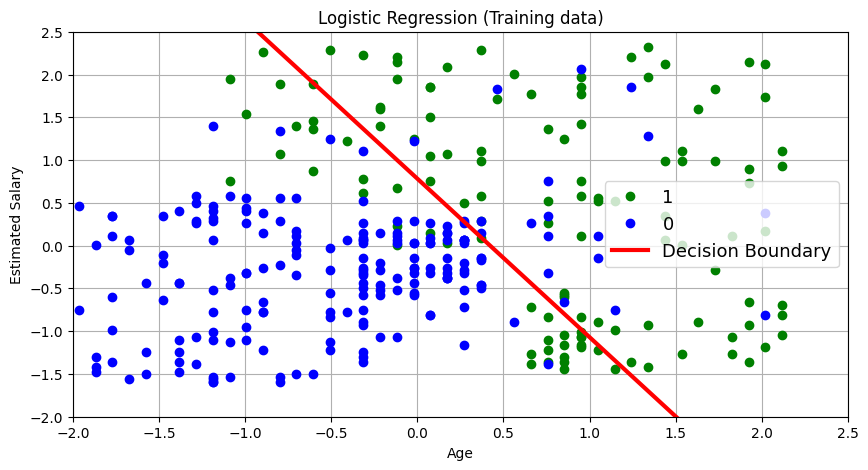

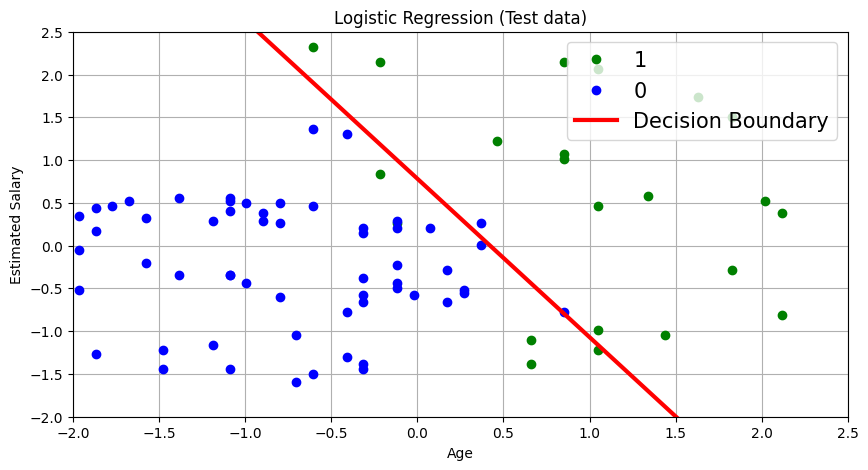

In [191]:
#6. 모델의 시각화

X_train_plot = X_train[:, 1:]
X_test_plot = X_test[:, 1:]

X2 = X_train_plot[y_train.ravel() == 1]
X1 = X_train_plot[y_train.ravel() == 0]
X2_test = X_test_plot[y_test.ravel() == 1]
X1_test = X_test_plot[y_test.ravel() == 0]

#분류 경계선
xp = np.linspace(-2,2.5,100).reshape(-1,1)
yp = - w[1]/w[2] * xp - w[0]/w[2]

# 학습데이터 시각화
plt.figure(figsize=(10, 5))
plt.plot(X2[:, 0], X2[:, 1], 'go', markersize=6, label='1')
plt.plot(X1[:, 0], X1[:, 1], 'bo', markersize=6, label='0')
plt.plot(xp, yp, 'r', linewidth = 3, label = 'Decision Boundary')
plt.title("Logistic Regression (Training data)")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend(fontsize=13)
plt.grid()
plt.xlim([-2, 2.5])
plt.ylim([-2, 2.5])
plt.show()

# 테스트테이터 시각화
plt.figure(figsize=(10, 5))
plt.plot(X2_test[:, 0], X2_test[:, 1], 'go', markersize=6, label='1')
plt.plot(X1_test[:, 0], X1_test[:, 1], 'bo', markersize=6, label='0')
plt.plot(xp, yp, 'r', linewidth = 3, label = 'Decision Boundary')
plt.title("Logistic Regression (Test data)")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend(fontsize=15)
plt.grid()
plt.xlim([-2, 2.5])
plt.ylim([-2, 2.5])
plt.show()

-0.870678343817608 2.0031927167477743 1.080672305315253


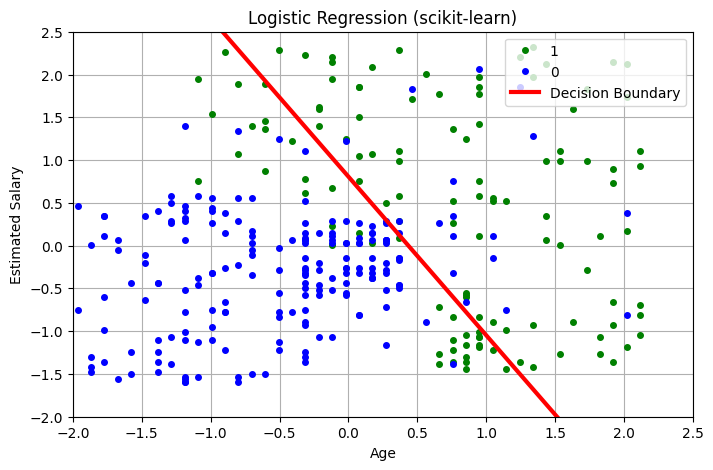

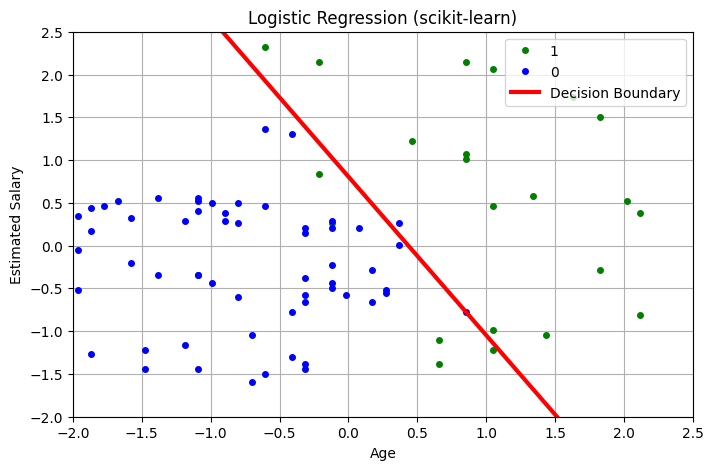

In [210]:
# 7.scikit-learn-Library를 이용, 모델 학습 및 파라미터 값 출력

# Feature & Label 추출
X = data[['Age', 'EstimatedSalary']].values
y = data['Purchased'].values

# 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 데이터 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn import linear_model

clf = linear_model.LogisticRegression(solver = 'lbfgs')
#clf.fit(X, np.ravel(y))
clf.fit(X_train, y_train.ravel())

w0 = clf.intercept_[0]
w1 = clf.coef_[0,0]
w2 = clf.coef_[0,1]
print(w0, w1, w2)

#8. 모델의 시각화
X_train_plot = X_train[:, 1:]
X_test_plot = X_test[:, 1:]

X2 = X_train[y_train.ravel() == 1]
X1 = X_train[y_train.ravel() == 0]
X2_test = X_test[y_test.ravel() == 1]
X1_test = X_test[y_test.ravel() == 0]

#분류 경계선
xp = np.linspace(-2, 2.5, 100).reshape(-1, 1)
yp = -w1 / w2 * xp - w0 / w2

# 학습데이터 시각화
plt.figure(figsize=(8, 5))
plt.plot(X2[:, 0], X2[:, 1], 'go', markersize=4, label='1')
plt.plot(X1[:, 0], X1[:, 1], 'bo', markersize=4, label='0')
plt.plot(xp, yp, 'r', linewidth = 3, label = 'Decision Boundary')
plt.title('Logistic Regression (scikit-learn)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend(loc=1)
plt.grid()
plt.xlim([-2, 2.5])
plt.ylim([-2, 2.5])
plt.show()

# 테스트 데이터 시각화
plt.figure(figsize=(8, 5))
plt.plot(X2_test[:, 0], X2_test[:, 1], 'go', markersize=4, label='1')
plt.plot(X1_test[:, 0], X1_test[:, 1], 'bo', markersize=4, label='0')
plt.plot(xp, yp, 'r', linewidth=3, label='Decision Boundary')
plt.title('Logistic Regression (scikit-learn)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend(loc=1)
plt.grid()
plt.xlim([-2, 2.5])
plt.ylim([-2, 2.5])
plt.show()